# Data Science

This notebook is a place to consolidate my learning of data science techniques and a reference for when I forget things. I've tried to explain everything in my own words so when I review it, it'll make sense to me.

## Laying the foundations

For me at least, the maths is not optional.

At each stage it's important to define the specific problem being solved. Whilst each step builds on the next, it's important to remember the context for the solution as what applies at the start doesn't necessarily apply at the end.

## Univariate Linear Regression

AKA linear regression with one variable.

This is a good place to start.

A simple 2D plot with a input on the x axis and a prediction on the y axis.



In [1]:


import plotly

In [2]:
import numpy as np
# TODO: What is numpy anyway?
# Create a section on linear algebra and how it is used in numpy to calculate "things" efficiently.

# Create a section on calculus to better describe the cost function and gradient descent.
# Start by solving things algebraically, then show how this quickly breaks down and gradient descent only requires the partial derivative.

# When are things for certain a convex function and when can you not be sure?
# Things are certain when the cost function is $$1/2(y-y_hat)^
# When is it possible to know if you are in a global minimum vs a local minimum?

In [3]:
x_train = np.array([1.0, 2.0])   #(size in 1000 square feet)
y_train = np.array([300.0, 500.0])

## Regression with multiple input variables

Stop thinking about data as a table. Instead, think of a row as a vector in a matrix.

We are basically saying that any given target variable is the dot product of the input variables and some, to be calculated weights.

$$ f_{\mathbf{w},b}(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b $$

Or in the expanded form:

$$ f_{\mathbf{w},b}(\mathbf{x}) = w_1x_1 + w_2x_2 + \dots + w_nx_n + b $$

$\mathbf{x}$ is a vector or row of values from a table.


In [4]:
w = np.array([1.0, 2.5, -3.3])
b = 4
x = np.array([10, 20, 30])

In [5]:
f = w[0]*x[0] + w[1]*x[1] + w[2]*x[2] + b
f

np.float64(-35.0)

In [6]:
total = 0
for i in range(len(w)):
    total += w[i]*x[i]

total + b

np.float64(-35.0)

## Vectorization

In [7]:
f = np.dot(w, x) + b
f

np.float64(-35.0)

## What if I think my target variable scales with an x^2 term?

Polynomials are "Linear in Parameters"
Even though a polynomial like $y = w_2x^2 + w_1x + b$ in non-linear with respect to x, it is linear with respect to the coefficients $(w_2, w_1, b)$.

If each power of x is treated as a separate feature e.g. $z_1 = x, z_2 = x^2$, the equation becomes $y = w_2z + w_1x + b$.

Using ordinary least squares guarantees that you'll find the minimum value, the

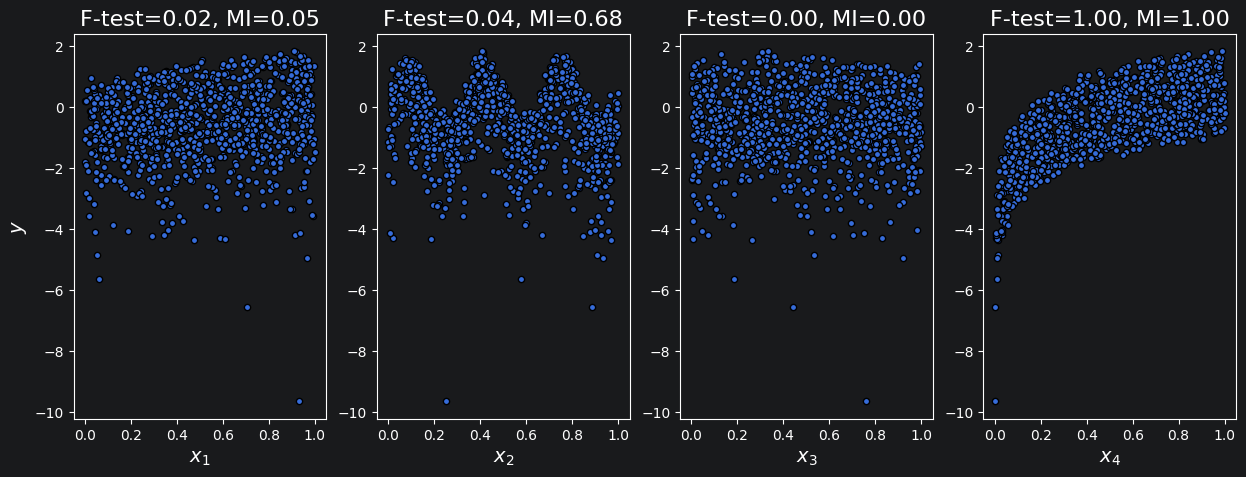

In [10]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.pyplot as plt
import numpy as np

from sklearn.feature_selection import f_regression, mutual_info_regression

np.random.seed(0)
X = np.random.rand(1000, 4)
y = X[:, 0] + np.sin(6 * np.pi * X[:, 1]) + 0.1 * np.random.randn(1000) + np.log(X[:, 3])

f_test, _ = f_regression(X, y)
f_test /= np.max(f_test)

mi = mutual_info_regression(X, y)
mi /= np.max(mi)

plt.figure(figsize=(15, 5))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.scatter(X[:, i], y, edgecolor="black", s=20)
    plt.xlabel("$x_{}$".format(i + 1), fontsize=14)
    if i == 0:
        plt.ylabel("$y$", fontsize=14)
    plt.title("F-test={:.2f}, MI={:.2f}".format(f_test[i], mi[i]), fontsize=16)
plt.show()

In [30]:
# Understand the cost of TP, TN, FP, FN.
# Understanding of unbalanced datasets.
# Logistic regression doesn't optimise a specific metric of your choosing.


In [11]:
X

array([[0.5488135 , 0.71518937, 0.60276338, 0.54488318],
       [0.4236548 , 0.64589411, 0.43758721, 0.891773  ],
       [0.96366276, 0.38344152, 0.79172504, 0.52889492],
       ...,
       [0.37634146, 0.06177907, 0.38546963, 0.24175052],
       [0.1877703 , 0.40467983, 0.11990391, 0.34963937],
       [0.43487363, 0.83000295, 0.93280618, 0.30833843]], shape=(1000, 4))

In [12]:
y

array([ 7.89664214e-01, -2.46137763e-01,  1.09923279e+00, -2.94908733e+00,
       -1.20098208e-01,  1.27774428e+00, -4.05997102e-01,  1.16720698e+00,
       -1.04330428e+00, -6.36054244e-01, -1.41467312e+00, -1.27016177e+00,
        6.99734103e-02,  7.37541375e-02, -1.79228361e+00, -8.91228663e-01,
       -1.43894867e+00,  1.05275446e+00, -3.06737130e+00, -9.52553773e-01,
        7.82999834e-01, -2.71367376e+00, -8.04460900e-01, -7.21357849e-01,
       -4.29303652e+00, -3.82503284e-01, -1.46231597e+00, -6.10539276e-01,
       -9.51603664e-01, -5.54166049e-01,  2.80683179e-01, -1.75050196e+00,
       -1.07385164e+00, -1.00092802e+00, -5.95608484e-01,  1.44330994e+00,
        1.31709548e+00,  4.82246635e-01, -8.44478140e-01, -2.72292592e+00,
        1.41278208e+00, -5.66512357e-01, -1.99598452e+00, -9.86948436e-01,
       -4.19389754e+00, -1.93487083e+00, -4.67617081e-01, -1.00822566e+00,
       -1.30818384e+00, -1.62283883e+00, -7.17002635e-01,  2.73658903e-01,
       -2.04445166e+00, -

In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
linear = LinearRegression()

In [15]:
linear.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
linear.score(X, y)

0.549241887767083

In [17]:
linear.coef_

array([ 0.8112258 , -0.88592147, -0.08712616,  3.0173929 ])

In [18]:
import pandas as pd
features = pd.DataFrame(X, columns=['x_1', 'x_2', 'x_3', 'x_4'])
target = pd.DataFrame(y, columns=['y'])

In [19]:
df = pd.concat([features, target], axis=1)

In [20]:
df.to_csv('dataset.csv')

<Axes: ylabel='Frequency'>

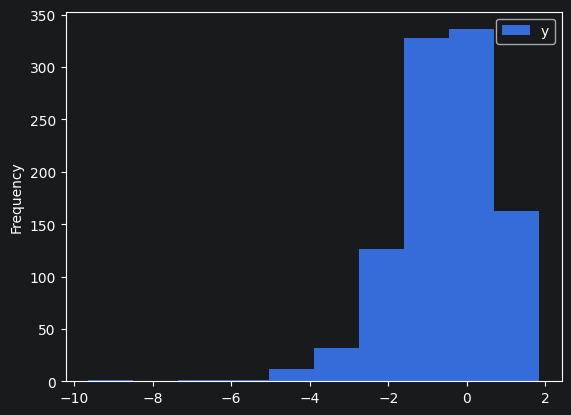

In [21]:
target.plot(kind='hist')

<Axes: xlabel='x_4', ylabel='y'>

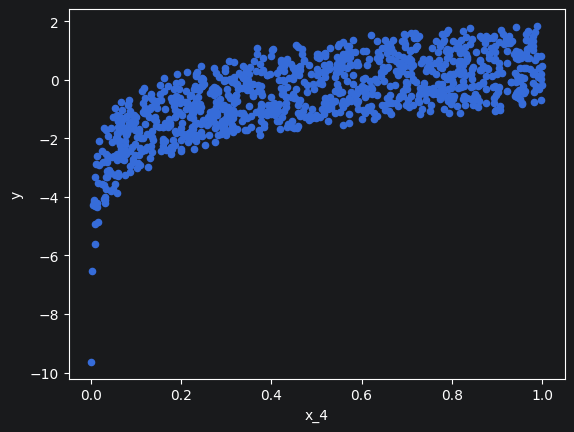

In [22]:
df.plot(x='x_4', y='y', kind='scatter')

In [23]:
df['e^y'] = np.exp(df['y'])

<Axes: xlabel='x_4', ylabel='e^y'>

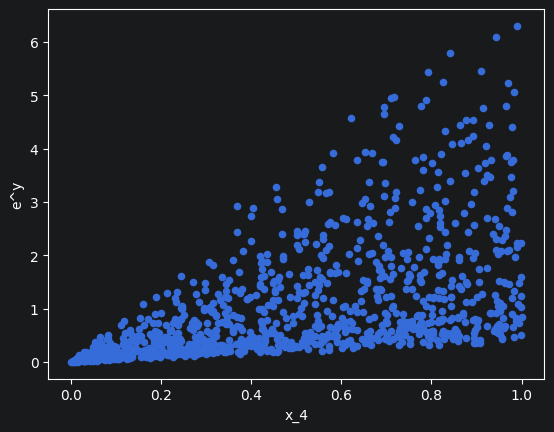

In [24]:
df.plot(x='x_4', y='e^y', kind='scatter')

In [25]:
df

,x_1,x_2,x_3,x_4,y,e^y
0,0.548814,0.715189,0.602763,0.544883,0.789664,2.202657
1,0.423655,0.645894,0.437587,0.891773,-0.246138,0.781815
2,0.963663,0.383442,0.791725,0.528895,1.099233,3.001862
3,0.568045,0.925597,0.071036,0.087129,-2.949087,0.052387
4,0.020218,0.832620,0.778157,0.870012,-0.120098,0.886833
...,...,...,...,...,...,...
995,0.432167,0.362259,0.558138,0.076344,-1.637770,0.194413
996,0.040346,0.511103,0.028501,0.059552,-3.178931,0.041630
997,0.376341,0.061779,0.385470,0.241751,-0.245576,0.782254
998,0.187770,0.404680,0.119904,0.349639,0.184542,1.202667


   Unnamed: 0       x_1       x_2       x_3       x_4         y
0           0  0.548814  0.715189  0.602763  0.544883  0.789664
1           1  0.423655  0.645894  0.437587  0.891773 -0.246138
2           2  0.963663  0.383442  0.791725  0.528895  1.099233
3           3  0.568045  0.925597  0.071036  0.087129 -2.949087
4           4  0.020218  0.832620  0.778157  0.870012 -0.120098
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1000 non-null   int64  
 1   x_1         1000 non-null   float64
 2   x_2         1000 non-null   float64
 3   x_3         1000 non-null   float64
 4   x_4         1000 non-null   float64
 5   y           1000 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 47.0 KB
None

Model Results:
Linear Regression: MSE = 1.0874, R2 = 0.4706
Random Forest: MSE = 0.3032, R2 = 0.8524
Gradient Boosting: MSE = 0.3003, R2 

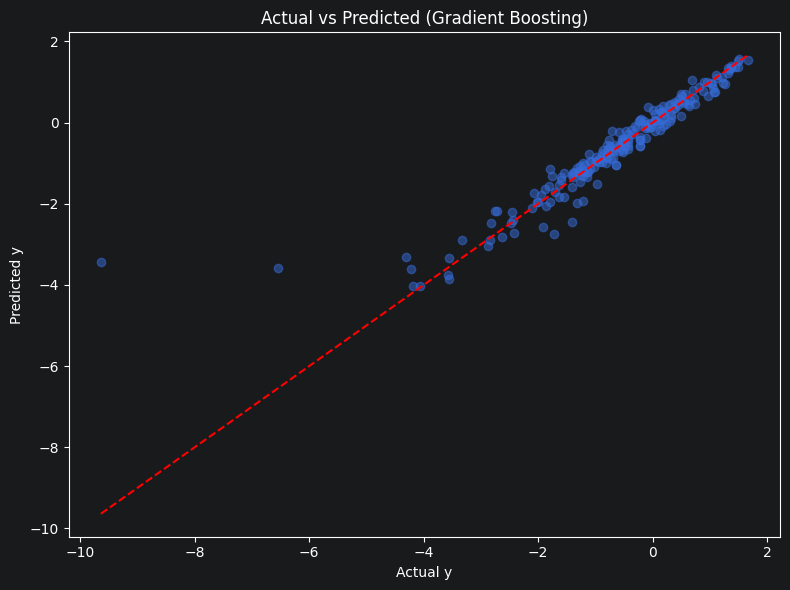

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('dataset.csv')
print(df.head())
print(df.info())

# Drop the index column if it exists
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

X = df.drop(columns=['y'])
y = df['y']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models to try
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': HistGradientBoostingRegressor(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MSE': mse, 'R2': r2}

print("\nModel Results:")
for name, metrics in results.items():
    print(f"{name}: MSE = {metrics['MSE']:.4f}, R2 = {metrics['R2']:.4f}")

# Plot best model (let's check which one is best, probably RF or GB)
best_model_name = max(results, key=lambda k: results[k]['R2'])
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual y')
plt.ylabel('Predicted y')
plt.title(f'Actual vs Predicted ({best_model_name})')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
print(f"\nSaved plot for {best_model_name}")

# Let's also check if there's a specific mathematical formula for Linear Regression
lr = models['Linear Regression']
print(f"\nLinear Regression Coefficients: {lr.coef_}")
print(f"Linear Regression Intercept: {lr.intercept_}")

In [27]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_test)

mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Polynomial Regression (degree=2): MSE = {mse_poly:.4f}, R2 = {r2_poly:.4f}")

poly_model3 = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
poly_model3.fit(X_train, y_train)
y_pred_poly3 = poly_model3.predict(X_test)
mse_poly3 = mean_squared_error(y_test, y_pred_poly3)
r2_poly3 = r2_score(y_test, y_pred_poly3)
print(f"Polynomial Regression (degree=3): MSE = {mse_poly3:.4f}, R2 = {r2_poly3:.4f}")

# Look at the coefficients of the degree 2 polynomial
poly_features = poly_model.named_steps['polynomialfeatures'].get_feature_names_out(X.columns)
coefs = poly_model.named_steps['linearregression'].coef_
intercept = poly_model.named_steps['linearregression'].intercept_

print(f"\nIntercept: {intercept}")
for name, coef in zip(poly_features, coefs):
    if abs(coef) > 0.1: # Only print significant coefficients
        print(f"{name}: {coef:.4f}")

Polynomial Regression (degree=2): MSE = 0.9049, R2 = 0.5594
Polynomial Regression (degree=3): MSE = 0.7533, R2 = 0.6332

Intercept: -2.8818819822797934
x_1: 0.6223
x_2: -0.5248
x_3: 0.8630
x_4: 7.4772
x_1^2: 0.2004
x_1 x_2: 0.2599
x_1 x_3: -0.2513
x_1 x_4: 0.1115
x_2^2: -0.4014
x_2 x_3: -0.1691
x_3^2: -0.5990
x_3 x_4: -0.2931
x_4^2: -4.4660


Saved partial dependence plot.
Correlations:
x_2   -0.196850
x_3   -0.014419
x_1    0.136444
x_4    0.688925
y      1.000000
Name: y, dtype: float64


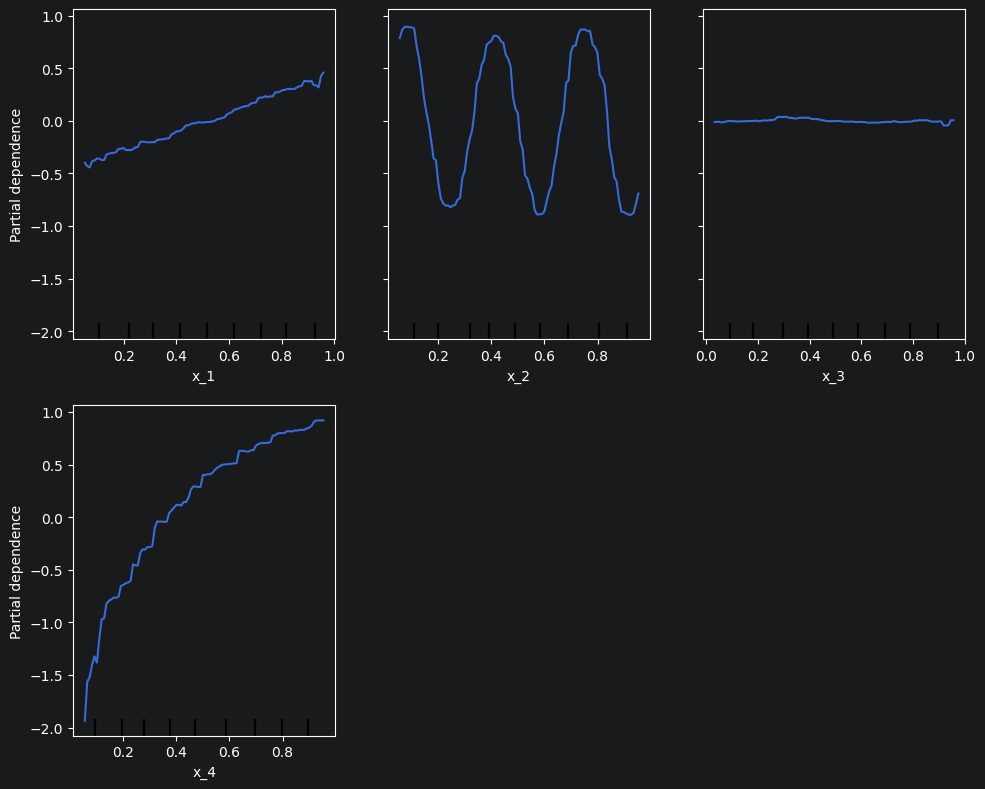

In [28]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(10, 8))
PartialDependenceDisplay.from_estimator(models['Gradient Boosting'], X_train, features=[0, 1, 2, 3], ax=ax)
plt.tight_layout()
plt.savefig('partial_dependence.png')
print("Saved partial dependence plot.")

# Checking correlations with target
print("Correlations:")
print(df.corr()['y'].sort_values())